## **Flight Delay Analysis and Prediction**

# **Read Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_parquet("Combined_Flights_2022.parquet")
df.head()

,FlightDate,Airline,Origin,Dest,Cancelled,Diverted,CRSDepTime,DepTime,DepDelayMinutes,DepDelay,...,WheelsOff,WheelsOn,TaxiIn,CRSArrTime,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,False,False,1133,1123.0,0.0,-10.0,...,1140.0,1220.0,8.0,1245,-17.0,0.0,-2.0,1200-1259,1,0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,False,False,732,728.0,0.0,-4.0,...,744.0,839.0,9.0,849,-1.0,0.0,-1.0,0800-0859,2,0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1529,1514.0,0.0,-15.0,...,1535.0,1622.0,14.0,1639,-3.0,0.0,-1.0,1600-1659,2,0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,False,False,1435,1430.0,0.0,-5.0,...,1446.0,1543.0,4.0,1605,-18.0,0.0,-2.0,1600-1659,2,0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,False,False,1135,1135.0,0.0,0.0,...,1154.0,1243.0,8.0,1245,6.0,0.0,0.0,1200-1259,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4078318 entries, 0 to 590541
Data columns (total 61 columns):
 #   Column                                   Dtype         
---  ------                                   -----         
 0   FlightDate                               datetime64[us]
 1   Airline                                  object        
 2   Origin                                   object        
 3   Dest                                     object        
 4   Cancelled                                bool          
 5   Diverted                                 bool          
 6   CRSDepTime                               int64         
 7   DepTime                                  float64       
 8   DepDelayMinutes                          float64       
 9   DepDelay                                 float64       
 10  ArrTime                                  float64       
 11  ArrDelayMinutes                          float64       
 12  AirTime                           

In [ ]:
columns = [
    'FlightDate',# Date (for trends)
    'Airline',          # Airline name
    'Origin',           # Source airport
    'Dest',             # Destination airport
    'DayOfWeek',        # Weekday pattern
    'CRSDepTime',       # Scheduled departure time
    'Distance',         # Travel distance
    'DepDelay',
    'ArrTime',
    'DepTime',# Departure delay (important signal)
    'ArrDelay',
    'ArrDel15'
]

In [ ]:
df = df[columns]

# **Data Cleaning**

In [ ]:
df.isnull().sum()

,0
FlightDate,0
Airline,0
Origin,0
Dest,0
DayOfWeek,0
CRSDepTime,0
Distance,0
DepDelay,120495
ArrTime,124239
DepTime,120433


In [ ]:
df = df.dropna(subset=['ArrDel15']) #Handle target column

In [ ]:
#Handle DepDelay & DepDelayMinutes
df['DepDelay'] = df['DepDelay'].fillna(0)
df['ArrTime'] = df['ArrTime'].fillna(0)
df['ArrDelay'] = df['ArrDelay'].fillna(0)
df['DepTime'] = df['DepTime'].fillna(0)

In [ ]:
df = df.drop_duplicates() #Remove duplicates

In [ ]:
df['Hour'] = df['CRSDepTime'] // 100

In [ ]:
df.isnull().sum()

,0
FlightDate,0
Airline,0
Origin,0
Dest,0
DayOfWeek,0
CRSDepTime,0
Distance,0
DepDelay,0
ArrTime,0
DepTime,0


In [ ]:
df.to_csv("cleaned_flight_data.csv", index=False) #This is the cleaned dataset.

In [ ]:
df.head()

,FlightDate,Airline,Origin,Dest,DayOfWeek,CRSDepTime,Distance,DepDelay,ArrTime,DepTime,ArrDelay,ArrDel15,Hour
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,1,1133,212.0,-10.0,1228.0,1123.0,-17.0,0.0,11
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,1,732,295.0,-4.0,848.0,728.0,-1.0,0.0,7
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,1,1529,251.0,-15.0,1636.0,1514.0,-3.0,0.0,15
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,1,1435,376.0,-5.0,1547.0,1430.0,-18.0,0.0,14
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,1,1135,251.0,0.0,1251.0,1135.0,6.0,0.0,11


# **Exploratory Data Analysis(EDA)**

**Delay Distribution**  

How many flights are delayed vs on-time? 0 → On-time, 1 → Delayed

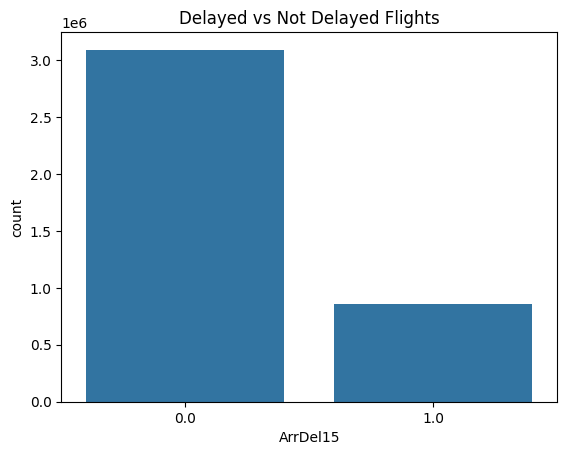

In [ ]:
sns.countplot(x='ArrDel15', data=df)
plt.title("Delayed vs Not Delayed Flights")
plt.show()

“The dataset shows that a significant portion of flights experience delays, indicating that delay prediction is a meaningful problem.”

**Airline-wise Delay Analysis**  
Which airline has the highest delays?

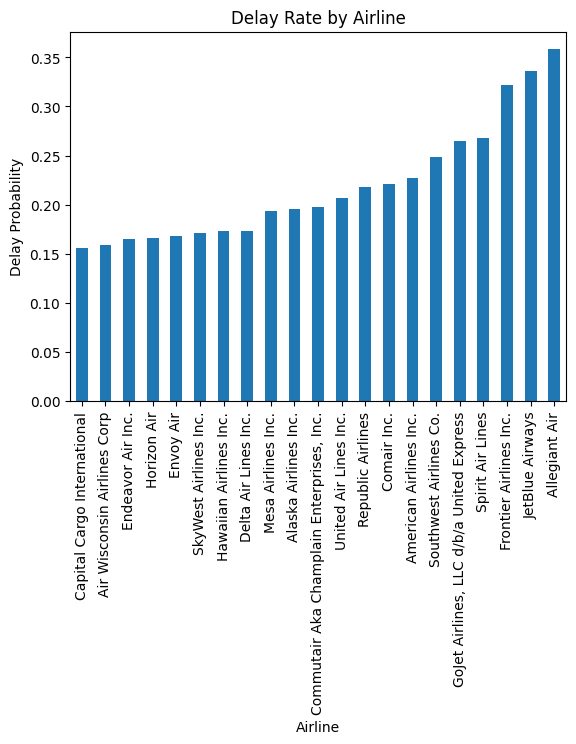

In [ ]:
airline_delay = df.groupby('Airline')['ArrDel15'].mean().sort_values()

airline_delay.plot(kind='bar')
plt.title("Delay Rate by Airline")
plt.ylabel("Delay Probability")
plt.show()

“Certain airlines show consistently higher delay probabilities, indicating operational inefficiencies.”

**Time-based Delay Analysis**  
At what time do delays happen most?

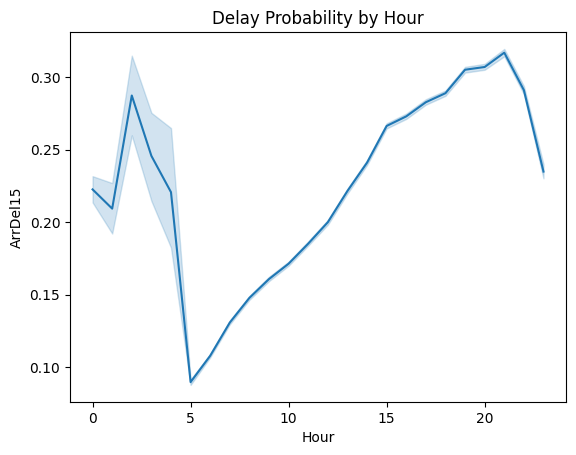

In [ ]:
sns.lineplot(x='Hour', y='ArrDel15', data=df)
plt.title("Delay Probability by Hour")
plt.show()

“Flights scheduled during evening hours show higher delay probability, likely due to congestion and accumulated delays.”

**Day of Week Analysis**  
Which day has more delays?

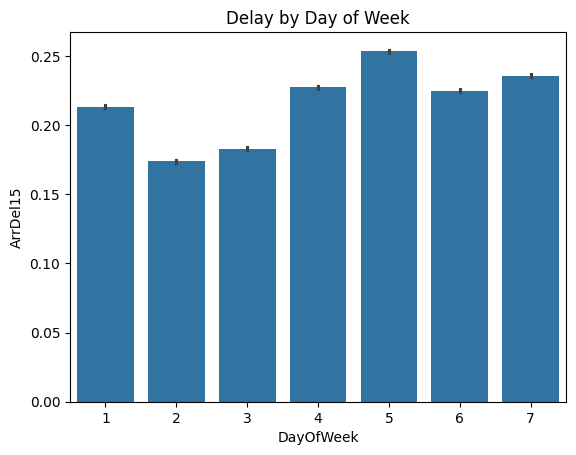

In [ ]:
sns.barplot(x='DayOfWeek', y='ArrDel15', data=df)
plt.title("Delay by Day of Week")
plt.show()

“Certain days of the week exhibit higher delay patterns, possibly due to increased travel demand.”

# **Feature Engineering**  
Creating new useful features from existing data.

In [ ]:
df['CRSDepTime'] = pd.to_datetime(df['CRSDepTime'], format='%H%M', errors='coerce')

In [ ]:
df['Hour'] = df['CRSDepTime'].dt.hour

In [ ]:
df['Hour'].isna().sum()

np.int64(594)

In [ ]:
df = df.dropna(subset=['CRSDepTime', 'Hour'])

In [ ]:
df[['CRSDepTime', 'Hour']].head()

,CRSDepTime,Hour
0,1900-01-01 11:33:00,11.0
1,1900-01-01 07:32:00,7.0
2,1900-01-01 15:29:00,15.0
3,1900-01-01 14:35:00,14.0
4,1900-01-01 11:35:00,11.0


In [ ]:
df['Route'] = df['Origin'] + "-" + df['Dest']
df[['Route']].head()

,Route
0,GJT-DEN
1,HRL-IAH
2,DRO-DEN
3,IAH-GPT
4,DRO-DEN


In [ ]:
def delay_severity(x):
    if x <= 0:
        return "On Time"
    elif x <= 15:
        return "Minor Delay"
    elif x <= 60:
        return "Moderate Delay"
    else:
        return "Severe Delay"

df['DelaySeverity'] = df['DepDelay'].apply(delay_severity)

In [ ]:
df[['DelaySeverity']].head()

,DelaySeverity
0,On Time
1,On Time
2,On Time
3,On Time
4,On Time


In [ ]:
def time_slot(hour):
    if hour < 12:
        return "Morning"
    elif hour < 16:
        return "Afternoon"
    elif hour < 20:
        return "Evening"
    else:
        return "Night"

df['TimeSlot'] = df['Hour'].apply(time_slot)

#0-11 → Morning, 12-17 → Afternoon, 18-23 → Evening

In [ ]:
df[['TimeSlot']].head()

,TimeSlot
0,Morning
1,Morning
2,Afternoon
3,Afternoon
4,Morning


In [ ]:
df['Month'] = df['FlightDate'].dt.month
df[['Month']].head()

,Month
0,4
1,4
2,4
3,4
4,4


In [ ]:
df['IsWeekend'] = df['DayOfWeek'].apply(lambda x: 1 if x in [6,7] else 0)
df[['IsWeekend']].head(10)

,IsWeekend
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


In [ ]:
df['PeakHour'] = df['Hour'].apply(lambda x: 1 if 7 <= x <= 10 or 17 <= x <= 20 else 0)
df[['PeakHour']].head()

,PeakHour
0,0
1,1
2,0
3,0
4,0


In [ ]:
df['DelayFlag'] = df['DepDelay'].apply(lambda x: 1 if x > 0 else 0)
df[['DelayFlag']].head()

,DelayFlag
0,0
1,0
2,0
3,0
4,0


target (y)  
This column indicates flight is delayed or not.  
1 - delayed
0 - ontime

In [ ]:
df.columns

Index(['FlightDate', 'Airline', 'Origin', 'Dest', 'DayOfWeek', 'CRSDepTime',
       'Distance', 'DepDelay', 'ArrTime', 'DepTime', 'ArrDelay', 'ArrDel15',
       'Hour', 'Route', 'DelaySeverity', 'TimeSlot', 'Month', 'IsWeekend',
       'PeakHour', 'DelayFlag'],
      dtype='object')

In [ ]:
df.head()

,FlightDate,Airline,Origin,Dest,DayOfWeek,CRSDepTime,Distance,DepDelay,ArrTime,DepTime,ArrDelay,ArrDel15,Hour,Route,DelaySeverity,TimeSlot,Month,IsWeekend,PeakHour,DelayFlag
0,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,1,1900-01-01 11:33:00,212.0,-10.0,1228.0,1123.0,-17.0,0.0,11.0,GJT-DEN,On Time,Morning,4,0,0,0
1,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,1,1900-01-01 07:32:00,295.0,-4.0,848.0,728.0,-1.0,0.0,7.0,HRL-IAH,On Time,Morning,4,0,1,0
2,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,1,1900-01-01 15:29:00,251.0,-15.0,1636.0,1514.0,-3.0,0.0,15.0,DRO-DEN,On Time,Afternoon,4,0,0,0
3,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,1,1900-01-01 14:35:00,376.0,-5.0,1547.0,1430.0,-18.0,0.0,14.0,IAH-GPT,On Time,Afternoon,4,0,0,0
4,2022-04-04,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,1,1900-01-01 11:35:00,251.0,0.0,1251.0,1135.0,6.0,0.0,11.0,DRO-DEN,On Time,Morning,4,0,0,0


In [ ]:
df.shape

(3944322, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3944322 entries, 0 to 590539
Data columns (total 20 columns):
 #   Column         Dtype         
---  ------         -----         
 0   FlightDate     datetime64[us]
 1   Airline        object        
 2   Origin         object        
 3   Dest           object        
 4   DayOfWeek      int64         
 5   CRSDepTime     datetime64[ns]
 6   Distance       float64       
 7   DepDelay       float64       
 8   ArrTime        float64       
 9   DepTime        float64       
 10  ArrDelay       float64       
 11  ArrDel15       float64       
 12  Hour           float64       
 13  Route          object        
 14  DelaySeverity  object        
 15  TimeSlot       object        
 16  Month          int32         
 17  IsWeekend      int64         
 18  PeakHour       int64         
 19  DelayFlag      int64         
dtypes: datetime64[ns](1), datetime64[us](1), float64(7), int32(1), int64(4), object(6)
memory usage: 616.9+ MB


In [ ]:
df['DelayFlag'].value_counts() #checking target distribution

,count
DelayFlag,
0,2393144
1,1551178


In [ ]:
df.groupby('Airline')['DelayFlag'].mean().sort_values(ascending=False) # more delayed airline

,DelayFlag
Airline,
Southwest Airlines Co.,0.563109
JetBlue Airways,0.506857
Allegiant Air,0.489014
Hawaiian Airlines Inc.,0.470744
Frontier Airlines Inc.,0.459769
United Air Lines Inc.,0.424159
Spirit Air Lines,0.413640
American Airlines Inc.,0.389985
Delta Air Lines Inc.,0.364648


In [ ]:
df.groupby('Hour')['DelayFlag'].mean() #which hr have more delay

,DelayFlag
Hour,
1.0,0.548726
2.0,0.473399
3.0,0.421801
4.0,0.408490
5.0,0.240665
6.0,0.216752
7.0,0.248278
8.0,0.284140
9.0,0.322744


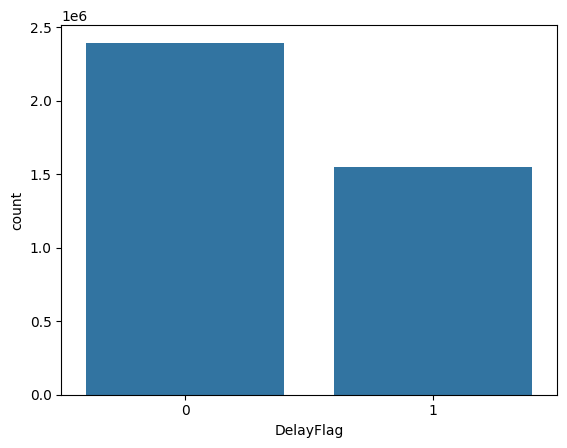

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='DelayFlag', data=df)
plt.show()

# **ML Model**

In [ ]:
df_model = df.drop(columns=[
    'DepDelay',
    'ArrDelay',
    'ArrDel15',
    'DelaySeverity',
    'FlightDate',
    'CRSDepTime',
    'ArrTime',
    'DepTime',
    'Route'
])
# not useful and cause data leakage

In [ ]:
df_model = df_model.dropna(subset=['Hour'])
df_model['Hour'] = df_model['Hour'].astype(int)

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3944322 entries, 0 to 590539
Data columns (total 11 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Airline    object 
 1   Origin     object 
 2   Dest       object 
 3   DayOfWeek  int64  
 4   Distance   float64
 5   Hour       int64  
 6   TimeSlot   object 
 7   Month      int32  
 8   IsWeekend  int64  
 9   PeakHour   int64  
 10  DelayFlag  int64  
dtypes: float64(1), int32(1), int64(5), object(4)
memory usage: 346.1+ MB


In [ ]:
cat_cols = ['Airline','Origin','Dest','TimeSlot']

for col in cat_cols:
    df_model[col] = df_model[col].astype('category')

In [ ]:
df['Distance'] = df['Distance'].astype('float32')
df['DayOfWeek'] = df['DayOfWeek'].astype('int8')
df['Month'] = df['Month'].astype('int8')
df['Hour'] = df['Hour'].astype('int8')
df['IsWeekend'] = df['IsWeekend'].astype('int8')
df['PeakHour'] = df['PeakHour'].astype('int8')
df['DelayFlag'] = df['DelayFlag'].astype('int8')

In [ ]:
X = df_model.drop('DelayFlag', axis=1)
y = df_model['DelayFlag']

In [ ]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

model.fit(X, y)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 1551178, number of negative: 2393144
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.406253 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 844
[LightGBM] [Info] Number of data points in the train set: 3944322, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.393269 -> initscore=-0.433593
[LightGBM] [Info] Start training from score -0.433593


LGBMClassifier(random_state=42)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

y_pred = model.predict(X_test)

In [ ]:
y_pred[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 0, 1])

In [ ]:
X_test['Predicted'] = y_pred
X_test['Actual'] = y_test.values
X_test.head(10)

,Airline,Origin,Dest,DayOfWeek,Distance,Hour,TimeSlot,Month,IsWeekend,PeakHour,Predicted,Actual
209433,American Airlines Inc.,RDU,DFW,7,1061.0,11,Morning,2,1,0,0,1
118131,Southwest Airlines Co.,MEM,ATL,5,332.0,18,Evening,2,0,1,1,1
69576,Southwest Airlines Co.,TPA,PIT,4,873.0,10,Morning,4,0,1,0,1
183544,Southwest Airlines Co.,HNL,ITO,7,216.0,20,Night,1,1,1,0,0
465261,Southwest Airlines Co.,IND,DEN,7,977.0,10,Morning,3,1,1,1,1
50493,Delta Air Lines Inc.,CMH,ATL,2,447.0,7,Morning,3,0,1,0,0
306315,Southwest Airlines Co.,AUS,MAF,4,294.0,21,Night,6,0,0,1,1
409742,United Air Lines Inc.,SFO,KOA,1,2367.0,11,Morning,3,0,0,0,0
567980,"Commutair Aka Champlain Enterprises, Inc.",TYS,IAH,2,771.0,7,Morning,4,0,1,0,0
481163,Southwest Airlines Co.,LAS,PHX,5,255.0,18,Evening,3,0,1,1,0


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.6873254612639679

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.86      0.77    479311
           1       0.66      0.42      0.51    309554

    accuracy                           0.69    788865
   macro avg       0.68      0.64      0.64    788865
weighted avg       0.68      0.69      0.67    788865


Confusion Matrix:

[[411991  67320]
 [179338 130216]]


# **Exploratory Data Analysis(EDA)**

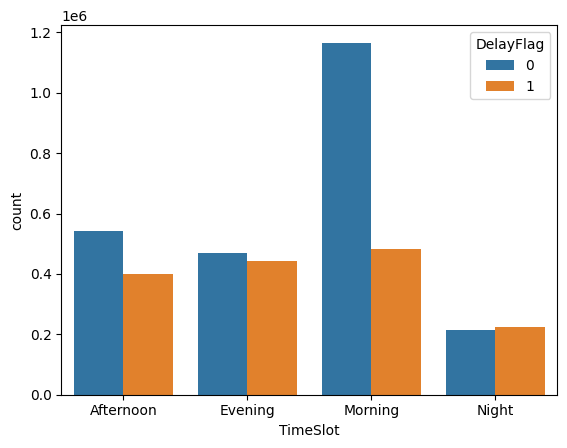

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='TimeSlot', hue='DelayFlag', data=df_model)
plt.show()

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(10)) #Which feature affects delay most

     Feature  Importance
1     Origin        1266
2       Dest         716
0    Airline         370
7      Month         229
5       Hour         176
3  DayOfWeek         160
4   Distance          74
6   TimeSlot           8
9   PeakHour           1
8  IsWeekend           0


In [ ]:
import joblib

joblib.dump(model, "flight_model.pkl")

['flight_model.pkl']

In [ ]:
import joblib

model = joblib.load("flight_model.pkl")

In [ ]:
from google.colab import files
files.download("flight_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(X.columns)

Index(['Airline', 'Origin', 'Dest', 'DayOfWeek', 'Distance', 'Hour',
       'TimeSlot', 'Month', 'IsWeekend', 'PeakHour'],
      dtype='object')


In [ ]:
df_model.to_csv("powerbi_dataset.csv", index=False)

In [ ]:
from google.colab import files

files.download("powerbi_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_model.head(10)

,Airline,Origin,Dest,DayOfWeek,Distance,Hour,TimeSlot,Month,IsWeekend,PeakHour,DelayFlag
0,"Commutair Aka Champlain Enterprises, Inc.",GJT,DEN,1,212.0,11,Morning,4,0,0,0
1,"Commutair Aka Champlain Enterprises, Inc.",HRL,IAH,1,295.0,7,Morning,4,0,1,0
2,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,1,251.0,15,Afternoon,4,0,0,0
3,"Commutair Aka Champlain Enterprises, Inc.",IAH,GPT,1,376.0,14,Afternoon,4,0,0,0
4,"Commutair Aka Champlain Enterprises, Inc.",DRO,DEN,1,251.0,11,Morning,4,0,0,0
5,"Commutair Aka Champlain Enterprises, Inc.",DEN,TUL,1,541.0,9,Morning,4,0,1,0
6,"Commutair Aka Champlain Enterprises, Inc.",IAH,LCH,1,127.0,21,Night,4,0,0,0
7,"Commutair Aka Champlain Enterprises, Inc.",TYS,IAH,1,771.0,11,Morning,4,0,0,0
8,"Commutair Aka Champlain Enterprises, Inc.",IAH,AEX,1,190.0,14,Afternoon,4,0,0,0
9,"Commutair Aka Champlain Enterprises, Inc.",IAH,MOB,1,427.0,9,Morning,4,0,1,0


In [ ]:
df_model['Origin'].unique()

['GJT', 'HRL', 'DRO', 'IAH', 'DEN', ..., 'GST', 'MVY', 'HYA', 'PIR', 'ATY']
Length: 375
Categories (375, object): ['ABE', 'ABI', 'ABQ', 'ABR', ..., 'XWA', 'YAK', 'YKM', 'YUM']

In [ ]:
df_model['Dest'].unique()

In [ ]:
df_model['Airline'].unique()

In [ ]:
df_model.to_csv("df_model.csv", index=False)

In [ ]:
df_model.shape